In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 1. Генерация данных (имитация логов API)
np.random.seed(42)
data_size = 5000
df = pd.DataFrame({
    'timestamp': pd.date_range('2026-03-01', periods=data_size, freq='S'),
    'endpoint': np.random.choice(['/get_media', '/search', '/user_profile'], data_size),
    'response_time_ms': np.random.exponential(scale=100, size=data_size) + np.random.normal(50, 10, data_size),
    'status_code': np.random.choice([200, 201, 404, 500], data_size, p=[0.95, 0.03, 0.01, 0.01])
})

C:\Users\krist\AppData\Local\Temp\ipykernel_51720\1405968108.py:5: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  'timestamp': pd.date_range('2026-03-01', periods=data_size, freq='S'),


In [4]:
# 2. Расчет ключевых метрик производительности (Перцентили)
latency_stats = df.groupby('endpoint')['response_time_ms'].agg([
    ('p50', lambda x: np.percentile(x, 50)),
    ('p95', lambda x: np.percentile(x, 95)),
    ('p99', lambda x: np.percentile(x, 99))
])

print("Статистика Latency по эндпоинтам (мс):")
print(latency_stats)

Статистика Latency по эндпоинтам (мс):
                      p50         p95         p99
endpoint                                         
/get_media     123.071791  339.739969  510.811195
/search        118.050630  344.201941  529.657460
/user_profile  120.994657  338.078297  514.147381


C:\Users\krist\AppData\Local\Temp\ipykernel_51720\1451935687.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='endpoint', y='response_time_ms', palette='Set3')


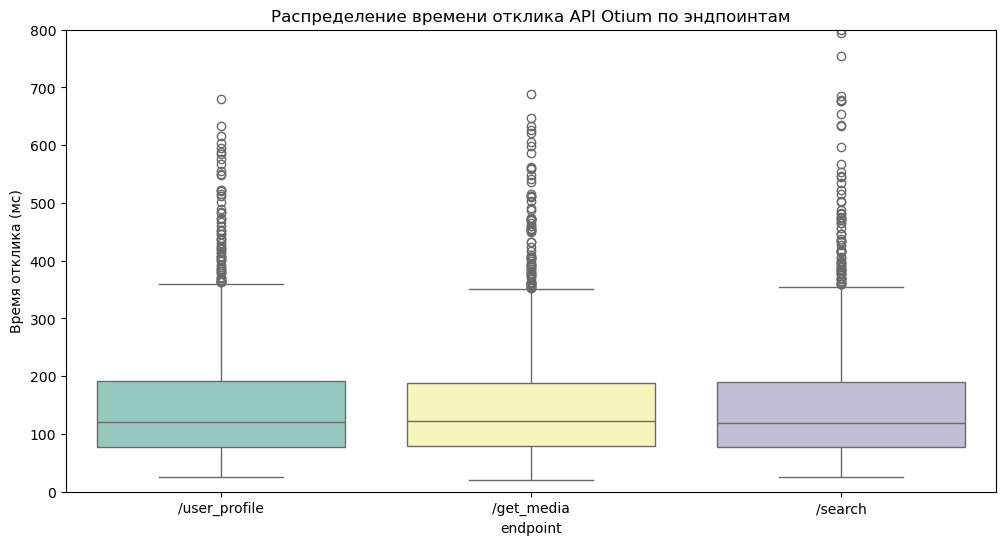

In [5]:
# 3. Визуализация распределения Latency
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='endpoint', y='response_time_ms', palette='Set3')
plt.title('Распределение времени отклика API Otium по эндпоинтам')
plt.ylabel('Время отклика (мс)')
plt.ylim(0, 800)
plt.show()

In [6]:
# 4. Анализ ошибок
error_rate = df[df['status_code'] >= 400].groupby('endpoint').size() / df.groupby('endpoint').size() * 100
print("\nПроцент ошибок по эндпоинтам (%):")
print(error_rate)


Процент ошибок по эндпоинтам (%):
endpoint
/get_media       1.898734
/search          2.317073
/user_profile    1.602959
dtype: float64
